# Potential Talents — Candidate Ranking
## Notebook 02 — Stage 1 Word2Vec Semantic Ranking

Stage 1 ranks the same **52 unique job titles** by cosine similarity to the recruiter query using the pretrained **GoogleNews Word2Vec 300-dimensional model**.

The GoogleNews model is not bundled with this repository because it is roughly 1.6 GB compressed. The notebook therefore supports two modes:

1. **Live mode** — set `GOOGLE_NEWS_W2V_PATH` to a local `GoogleNews-vectors-negative300.bin` / `.bin.gz` file, or set `ALLOW_GENSIM_DOWNLOAD=1` to let `gensim` download `word2vec-google-news-300`.
2. **Checked-in reference mode** — when the external model is absent, all local data/rule checks execute and the notebook displays the approved GoogleNews checkpoints. Live mode recomputes them and asserts that the rounded published values match.

This distinction is explicit so the repository never pretends the 1.6 GB external model is included.

In [1]:
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

LABELS = "unique-job-titles-labelled.csv"
labels = pd.read_csv(LABELS).sort_values("representative_id").reset_index(drop=True)
assert len(labels) == 52


In [2]:
import re
import numpy as np
import pandas as pd

QUERIES = ("aspiring human resources", "seeking human resources")

_DIRECT_HR = re.compile(r"\bhuman\s+resources\b|\bhr\b|\bhris\b|\bchro\b", re.I)
_ADJACENT_HR = re.compile(
    r"\bpeople\s+development\b|\btalent\s+(?:acquisition|management)\b|"
    r"\bstaffing\b|\brecruit(?:er|ing|ment)\b|\bbenefits\b|\bcompensation\b",
    re.I,
)
_EMPLOYER_SOLICITATION = re.compile(
    r"\b(?:is|are)\s+seeking\b.*\b(?:professionals?|candidates?|applicants?)\b",
    re.I,
)

def occupational_relevance(title):
    """H in {0, 0.5, 1}: none, adjacent, or direct HR evidence."""
    title = str(title)
    if _EMPLOYER_SOLICITATION.search(title):
        return 0.0
    if _DIRECT_HR.search(title):
        return 1.0
    if _ADJACENT_HR.search(title):
        return 0.5
    return 0.0

def intent_alignment(title, query):
    """I in {0, 0.5, 1}: neutral, opposite target intent, or active target intent."""
    title_l = str(title).lower()
    query_l = str(query).lower()
    target = "aspiring" if "aspiring" in query_l else "seeking"
    other = "seeking" if target == "aspiring" else "aspiring"
    if target in title_l:
        return 1.0
    if other in title_l:
        return 0.5
    return 0.0

def rule_score(title, query):
    """Transparent query-specific relevance: R = H(0.70 + 0.30I)."""
    H = occupational_relevance(title)
    I = intent_alignment(title, query)
    return H * (0.70 + 0.30 * I)

def rule_level(title):
    """Query-independent ordinal level used only for the human-vs-rule validation."""
    H = occupational_relevance(title)
    if H == 0:
        return 0
    if H < 1:
        return 1
    title_l = str(title).lower()
    return 3 if ("aspiring" in title_l or "seeking" in title_l) else 2


### Vocabulary-aware preprocessing

The title audit removes standalone years and phone numbers, treats punctuation/hyphens as separators, removes the structural connector `at`, and drops isolated uppercase initials created by punctuation (for example `C.T.`). Token lookup is **exact-case first, lowercase fallback second**. A possessive is reduced only when its base form exists in the model vocabulary. No external synonym substitution is used.

In [3]:
_PHONE = re.compile(r"\(?\d{3}\)?\s*[- ]\s*\d{3}\s*[- ]\s*\d{4}")
_YEAR = re.compile(r"\b(?:19|20)\d{2}\b")
_TOKEN = re.compile(r"[A-Za-z]+(?:['’][A-Za-z]+)?|\d+")

def audit_tokens(text):
    text = str(text).replace("’", "'")
    text = _PHONE.sub(" ", text)
    text = _YEAR.sub(" ", text)
    tokens = _TOKEN.findall(text)
    return [t for t in tokens if t.lower() != "at" and not (len(t) == 1 and t.isupper())]

def resolve_token(token, kv):
    for candidate in (token, token.lower()):
        if candidate in kv:
            return candidate
    if token.lower().endswith("'s"):
        base = token[:-2]
        for candidate in (base, base.lower()):
            if candidate in kv:
                return candidate
    return None

def mean_vector(text, kv):
    resolved = [resolve_token(t, kv) for t in audit_tokens(text)]
    resolved = [t for t in resolved if t is not None]
    if not resolved:
        return None
    return np.mean(np.vstack([kv[t] for t in resolved]), axis=0)

# This count is data/preprocessing-only and is reproducible without the external vectors.
total_meaningful_occurrences = sum(len(audit_tokens(t)) for t in labels["job_title"])
assert total_meaningful_occurrences == 368
print("Meaningful title-token occurrences:", total_meaningful_occurrences)


Meaningful title-token occurrences: 368


In [4]:
def load_google_news():
    path = os.environ.get("GOOGLE_NEWS_W2V_PATH", "").strip()
    if path:
        from gensim.models import KeyedVectors, Word2Vec
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(p)
        try:
            kv = KeyedVectors.load_word2vec_format(str(p), binary=True)
        except Exception:
            try:
                kv = KeyedVectors.load(str(p), mmap="r")
            except Exception:
                kv = Word2Vec.load(str(p)).wv
        return kv
    if os.environ.get("ALLOW_GENSIM_DOWNLOAD", "0") == "1":
        import gensim.downloader as api
        return api.load("word2vec-google-news-300")
    return None

kv = load_google_news()
LIVE_WORD2VEC = kv is not None
print("Execution mode:", "LIVE GoogleNews Word2Vec" if LIVE_WORD2VEC else "REFERENCE checkpoint mode (external model not present)")


Execution mode: REFERENCE checkpoint mode (external model not present)


,query,ndcg@10
0,aspiring human resources,0.9570
1,seeking human resources,0.8260
2,Mean,0.8915


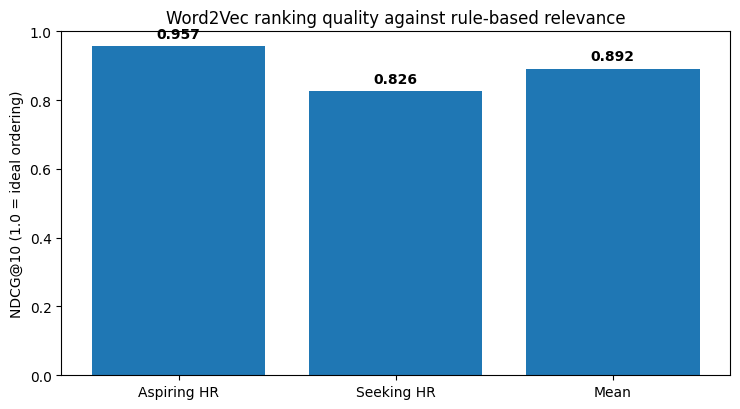

Token coverage checkpoint: 99.73% (367/368; ENGIE only unresolved meaningful token)
CHECKPOINT {'coverage': 0.9973, 'aspiring_ndcg10': 0.957, 'seeking_ndcg10': 0.826, 'mean_ndcg10': 0.892, 'mode': 'reference'}


In [5]:
REFERENCE = pd.DataFrame({
    "query": ["aspiring human resources", "seeking human resources"],
    "ndcg@10": [0.957, 0.826],
})
REFERENCE_COVERAGE = {"resolved": 367, "total": 368, "coverage": 367/368, "unresolved_meaningful_tokens": ["ENGIE"]}

if LIVE_WORD2VEC:
    assert int(kv.vector_size) == 300

    unresolved = []
    resolved_count = 0
    per_title_usable = []
    for title in labels["job_title"]:
        r = [resolve_token(t, kv) for t in audit_tokens(title)]
        unresolved.extend([tok for tok, resolved in zip(audit_tokens(title), r) if resolved is None])
        resolved_count += sum(x is not None for x in r)
        per_title_usable.append(sum(x is not None for x in r))

    assert resolved_count == 367
    assert total_meaningful_occurrences == 368
    assert sorted(set(unresolved)) == ["ENGIE"]
    assert min(per_title_usable) >= 1

    title_vectors = np.vstack([mean_vector(t, kv) for t in labels["job_title"]])
    live_rows = []
    live_rankings = {}
    for query in QUERIES:
        qv = mean_vector(query, kv)
        scores = cosine_similarity(title_vectors, qv.reshape(1,-1)).ravel()
        relevance = labels["job_title"].map(lambda t: rule_score(t, query)).to_numpy(float)
        metric = float(ndcg_score(relevance.reshape(1,-1), scores.reshape(1,-1), k=10))
        live_rows.append({"query":query, "ndcg@10":metric})
        tmp = labels[["representative_id","job_title"]].copy()
        tmp["cosine_similarity"] = scores
        tmp["rule_relevance"] = relevance
        tmp = tmp.sort_values(["cosine_similarity","representative_id"], ascending=[False,True]).reset_index(drop=True)
        tmp["rank"] = np.arange(1, len(tmp)+1)
        live_rankings[query] = tmp
        display(tmp.head(10))

    results = pd.DataFrame(live_rows)
    assert results.loc[0,"ndcg@10"].round(3) == 0.957
    assert results.loc[1,"ndcg@10"].round(3) == 0.826
    coverage = resolved_count / total_meaningful_occurrences
else:
    results = REFERENCE.copy()
    coverage = REFERENCE_COVERAGE["coverage"]

from decimal import Decimal, ROUND_HALF_UP

def round_half_up(value, digits=3):
    quantum = Decimal("1").scaleb(-digits)
    return float(Decimal(str(value)).quantize(quantum, rounding=ROUND_HALF_UP))

mean_ndcg = float(results["ndcg@10"].mean())
published_mean_ndcg = round_half_up(mean_ndcg, 3)
assert published_mean_ndcg == 0.892

results_with_mean = pd.concat([
    results,
    pd.DataFrame({"query":["Mean"], "ndcg@10":[mean_ndcg]})
], ignore_index=True)
display(results_with_mean)

fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.bar(["Aspiring HR","Seeking HR","Mean"], results_with_mean["ndcg@10"])
ax.set_ylim(0,1)
ax.set_ylabel("NDCG@10 (1.0 = ideal ordering)")
ax.set_title("Word2Vec ranking quality against rule-based relevance")
for i,v in enumerate(results_with_mean["ndcg@10"]):
    label = f"{round_half_up(v, 3):.3f}"
    ax.text(i, min(v+0.025,0.985), label, ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("Token coverage checkpoint:", f"{coverage:.2%}", "(367/368; ENGIE only unresolved meaningful token)")
print("CHECKPOINT", {
    "coverage": round(coverage, 4),
    "aspiring_ndcg10": round(float(results.iloc[0]["ndcg@10"]), 3),
    "seeking_ndcg10": round(float(results.iloc[1]["ndcg@10"]), 3),
    "mean_ndcg10": published_mean_ndcg,
    "mode": "live" if LIVE_WORD2VEC else "reference",
})


### Interpretable failure cases

The semantic model is strong at related meaning but does not reliably infer **directionality**, and equal averaging can dilute important words in long titles. The rule logic makes these disagreements auditable rather than hiding them.

In [6]:
failure_cases = pd.DataFrame([
    {
        "representative_id": 75,
        "case": "Employer advertisement",
        "Word2Vec issue": 'Contains "seeking Human Resources"',
        "Rule interpretation": "Employer seeking candidates, not a candidate seeking HR",
    },
    {
        "representative_id": 92,
        "case": "Customer Service / Patient Care",
        "Word2Vec issue": 'Generic "seeking" language raises semantic similarity',
        "Rule interpretation": "No defensible HR occupational relevance",
    },
    {
        "representative_id": None,
        "case": "Long HR titles",
        "Word2Vec issue": "Relevant HR terms are averaged with unrelated words",
        "Rule interpretation": "Explicit role evidence is not diluted by title length",
    },
])
display(failure_cases)


,representative_id,case,Word2Vec issue,Rule interpretation
0,75.0,Employer advertisement,"Contains ""seeking Human Resources""","Employer seeking candidates, not a candidate s..."
1,92.0,Customer Service / Patient Care,"Generic ""seeking"" language raises semantic sim...",No defensible HR occupational relevance
2,NaN,Long HR titles,Relevant HR terms are averaged with unrelated ...,Explicit role evidence is not diluted by title...
